# AV Job Classifier Comparison

Compares four approaches to the AV-relevance binary classification task (is this job posting
about autonomous-vehicle engineering work, yes/no), all trained/evaluated on the exact same
labeled seed and the exact same held-out split, so the numbers are directly comparable:

| Backend | Mechanism | Needs labeled data? |
|---|---|---|
| **TF-IDF** | Bag-of-words features + logistic regression | Yes (fits from scratch) |
| **Embedding** | Frozen pretrained sentence embeddings + logistic regression | Yes (fits a linear probe) |
| **SetFit** | Fine-tunes the sentence transformer itself via contrastive pairs, then a classification head | Yes (few-shot) |
| **Zero-shot** | BART-large-MNLI natural-language-inference, no training at all | No |

This reuses the same classifier classes already built and unit-tested in
`scrapers/service/ml/` - the notebook doesn't reimplement any classification logic, it just
runs and compares them.

**Data**: the LLM-labeled seed already produced by `scrapers/utils/job_classifier.py
--sample-size` (real Groq labels, not another model's predictions) - loaded fresh from
`data/job_classification/av_candidates.jsonl` / `non_av_jobs.jsonl`, filtered to
`_source != "classifier"` so this is ground truth, not circular.

**Note on cost**: SetFit fine-tunes an actual transformer (~10 min on GPU, longer on CPU) and
zero-shot downloads BART-large-MNLI (~1.6GB) and runs inference for every example. Toggle
`RUN_SETFIT` / `RUN_ZEROSHOT` below to skip either if you just want the fast TF-IDF/embedding
comparison.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

RUN_SETFIT = True
RUN_ZEROSHOT = True
TEST_SIZE = 0.2
SPLIT_SEED = 42


## Load the labeled seed

Ground-truth only - excludes any record another classifier has already labeled, so training/evaluation here is never circular.

In [2]:
import json

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

def is_llm_labeled(record):
    return record.get("_classification", {}).get("_source") not in ("classifier", "classifier_forced")

data_dir = PROJECT_ROOT / "data" / "job_classification"
av_records = [r for r in load_jsonl(data_dir / "av_candidates.jsonl") if is_llm_labeled(r)]
non_av_records = [r for r in load_jsonl(data_dir / "non_av_jobs.jsonl") if is_llm_labeled(r)]

print(f"AV examples:     {len(av_records)}")
print(f"Non-AV examples: {len(non_av_records)}")
print(f"Total seed:      {len(av_records) + len(non_av_records)}")


AV examples:     205
Non-AV examples: 197
Total seed:      402


In [3]:
from scrapers.service.llm import JobFilterConfig
from scrapers.utils.job_classifier import _resolve

aliases = JobFilterConfig.load().field_aliases

def job_title_description(record):
    return _resolve(record, aliases, "title"), _resolve(record, aliases, "description")

records = av_records + non_av_records
labels = [True] * len(av_records) + [False] * len(non_av_records)
titles_descriptions = [job_title_description(r) for r in records]

print(f"Total labeled examples: {len(records)}")


Total labeled examples: 402


## Train/test split

Same split (stratified, fixed seed) used for every backend below, so results are directly comparable.

In [4]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    range(len(records)), test_size=TEST_SIZE, stratify=labels, random_state=SPLIT_SEED
)
train_records = [titles_descriptions[i] for i in train_idx]
train_labels = [labels[i] for i in train_idx]
test_records = [titles_descriptions[i] for i in test_idx]
test_labels = [labels[i] for i in test_idx]

print(f"Train: {len(train_records)}  ({sum(train_labels)} AV / {len(train_records) - sum(train_labels)} non-AV)")
print(f"Test:  {len(test_records)}  ({sum(test_labels)} AV / {len(test_records) - sum(test_labels)} non-AV)")


Train: 321  (164 AV / 157 non-AV)
Test:  81  (41 AV / 40 non-AV)


## Evaluation helper

Fits on train only, reports accuracy/precision/recall/F1 on both train and held-out test, so we can see the train/test gap (a rough overfitting signal) alongside raw performance.

In [5]:
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def evaluate(name, classifier, train_texts, train_labels_, test_texts, test_labels_):
    start = time.time()
    classifier.fit(train_texts, train_labels_)
    fit_seconds = time.time() - start

    train_pred = [p >= 0.5 for p in classifier.predict_proba(train_texts)]
    test_pred = [p >= 0.5 for p in classifier.predict_proba(test_texts)]

    train_acc = accuracy_score(train_labels_, train_pred)
    test_acc = accuracy_score(test_labels_, test_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        test_labels_, test_pred, average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(test_labels_, test_pred, labels=[False, True]).ravel()

    return {
        "backend": name,
        "fit_seconds": round(fit_seconds, 1),
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "overfit_gap": round(train_acc - test_acc, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp),
    }

results = []


## TF-IDF

Bag-of-words features (title repeated for extra weight, plus job_prefilter's keyword-match score folded in as a pseudo-word) + logistic regression.

In [6]:
from scrapers.service.ml.relevance_classifier import RelevanceClassifier, job_text

def prefilter_score(record):
    return record.get("_prefilter", {}).get("score")

def tfidf_texts(pairs, records_subset):
    return [job_text(title, desc, prefilter_score(r)) for (title, desc), r in zip(pairs, records_subset)]

train_records_full = [records[i] for i in train_idx]
test_records_full = [records[i] for i in test_idx]

tfidf_train_texts = tfidf_texts(train_records, train_records_full)
tfidf_test_texts = tfidf_texts(test_records, test_records_full)

results.append(evaluate("tfidf", RelevanceClassifier(), tfidf_train_texts, train_labels, tfidf_test_texts, test_labels))
results[-1]


{'backend': 'tfidf',
 'fit_seconds': 1.0,
 'train_accuracy': 0.9439,
 'test_accuracy': 0.8272,
 'overfit_gap': 0.1168,
 'precision': 0.8293,
 'recall': 0.8293,
 'f1': 0.8293,
 'true_negative': 33,
 'false_positive': 7,
 'false_negative': 7,
 'true_positive': 34}

## Embedding (frozen sentence-transformer + logistic regression)

No fine-tuning - a pretrained encoder run once, with a linear classifier trained on top of its fixed output.

In [7]:
from scrapers.service.ml.embedding_classifier import EmbeddingRelevanceClassifier

def natural_texts(pairs):
    return [f"{title}. {title}. {desc}" for title, desc in pairs]

emb_train_texts = natural_texts(train_records)
emb_test_texts = natural_texts(test_records)

results.append(evaluate("embedding", EmbeddingRelevanceClassifier(), emb_train_texts, train_labels, emb_test_texts, test_labels))
results[-1]


/home/martin/Autonomous_Vehicle_Job_Profiles_Group3/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13331.28it/s]

{'backend': 'embedding',
 'fit_seconds': 0.7,
 'train_accuracy': 0.8287,
 'test_accuracy': 0.8272,
 'overfit_gap': 0.0015,
 'precision': 0.8857,
 'recall': 0.7561,
 'f1': 0.8158,
 'true_negative': 36,
 'false_positive': 4,
 'false_negative': 10,
 'true_positive': 31}

## SetFit (fine-tuned sentence-transformer)

Actually updates the transformer's weights via contrastive pairs generated from the labeled seed, then trains a classification head. Slower - generates thousands of pairs even from a few hundred examples.

In [8]:
if RUN_SETFIT:
    from scrapers.service.ml.setfit_classifier import SetFitRelevanceClassifier

    results.append(evaluate("setfit", SetFitRelevanceClassifier(), emb_train_texts, train_labels, emb_test_texts, test_labels))
    display(results[-1])
else:
    print("Skipped (RUN_SETFIT = False)")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10428.55it/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Map:   0%|          | 0/321 [00:00<?, ? examples/s]

Map: 100%|██████████| 321/321 [00:00<00:00, 16942.74 examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 14.32it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.14it/s]

{'backend': 'setfit',
 'fit_seconds': 855.2,
 'train_accuracy': 1.0,
 'test_accuracy': 0.8272,
 'overfit_gap': 0.1728,
 'precision': 0.8857,
 'recall': 0.7561,
 'f1': 0.8158,
 'true_negative': 36,
 'false_positive': 4,
 'false_negative': 10,
 'true_positive': 31}

## Zero-shot (BART-large-MNLI, no training)

`fit()` is a no-op here - this baseline never sees the training labels, so its train/test gap is meaningless (just split noise), included for reference only.

In [9]:
if RUN_ZEROSHOT:
    from scrapers.service.ml.zeroshot_classifier import ZeroShotRelevanceClassifier

    results.append(evaluate("zeroshot", ZeroShotRelevanceClassifier(), emb_train_texts, train_labels, emb_test_texts, test_labels))
    display(results[-1])
else:
    print("Skipped (RUN_ZEROSHOT = False)")


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 12253.68it/s]

{'backend': 'zeroshot',
 'fit_seconds': 0.0,
 'train_accuracy': 0.5514,
 'test_accuracy': 0.6049,
 'overfit_gap': -0.0535,
 'precision': 0.5652,
 'recall': 0.9512,
 'f1': 0.7091,
 'true_negative': 10,
 'false_positive': 30,
 'false_negative': 2,
 'true_positive': 39}

## Comparison

In [10]:
import pandas as pd

comparison = pd.DataFrame(results).set_index("backend")
comparison[["test_accuracy", "precision", "recall", "f1", "train_accuracy", "overfit_gap", "fit_seconds"]]


,test_accuracy,precision,recall,f1,train_accuracy,overfit_gap,fit_seconds
backend,,,,,,,
tfidf,0.8272,0.8293,0.8293,0.8293,0.9439,0.1168,1.0
embedding,0.8272,0.8857,0.7561,0.8158,0.8287,0.0015,0.7
setfit,0.8272,0.8857,0.7561,0.8158,1.0000,0.1728,855.2
zeroshot,0.6049,0.5652,0.9512,0.7091,0.5514,-0.0535,0.0


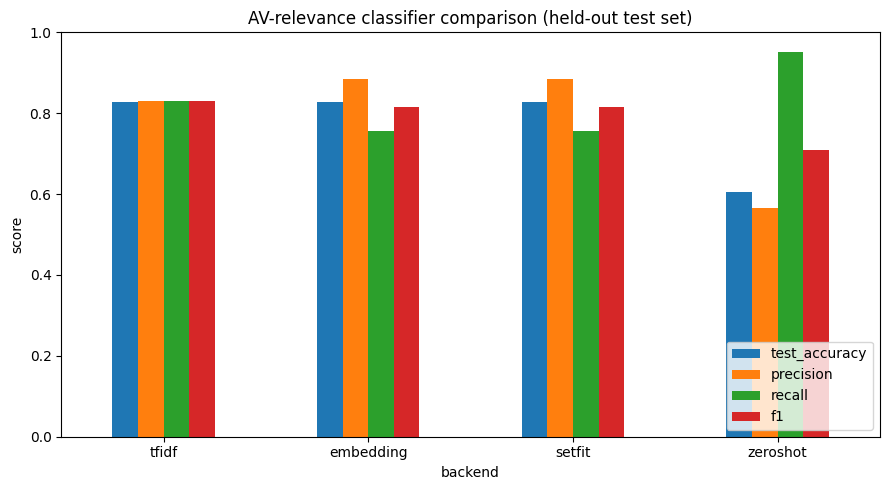

In [11]:
import matplotlib.pyplot as plt

metrics_to_plot = ["test_accuracy", "precision", "recall", "f1"]
ax = comparison[metrics_to_plot].plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("AV-relevance classifier comparison (held-out test set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Notes

- **TF-IDF** typically shows the highest raw test accuracy but also the largest train/test gap
  (a sign it's partly memorizing the small seed rather than purely generalizing) - its *true*
  reliability is likely closer to its test score minus some of that gap.
- **Embedding** (frozen) usually has the smallest train/test gap - what you see is close to
  what you get, even though its raw numbers are a bit lower than TF-IDF's.
- **SetFit** tends to win on precision (fewest false "AV" labels) at the cost of recall - useful
  if false positives are more costly than false negatives for your use case.
- **Zero-shot** needs no labeled data at all but is consistently the weakest here - this specific
  "AV job vs not" distinction needs the domain calibration a labeled seed provides; generic
  pretrained knowledge alone isn't enough.
- None of these are validated much above ~85% accuracy - the seed size (currently a few hundred
  examples) is the shared bottleneck. Growing it is the highest-leverage next step for all four.
